# Clase 18/03/2026
Codigo usado Gen_sen_propio.py

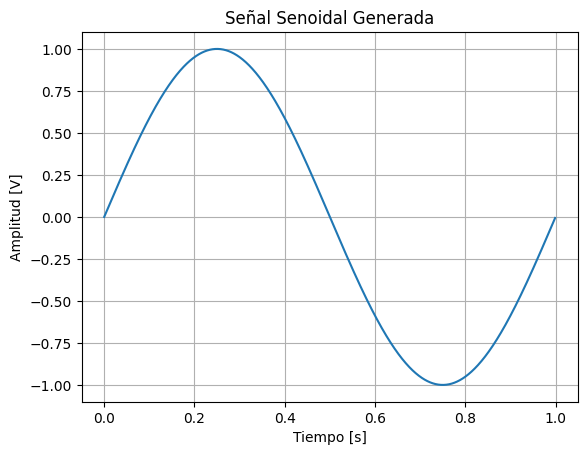

Varianza de error de cuantizacion:  0.0034051647914073264
varianza teorica de error de cuantizacion:  0.0029296875


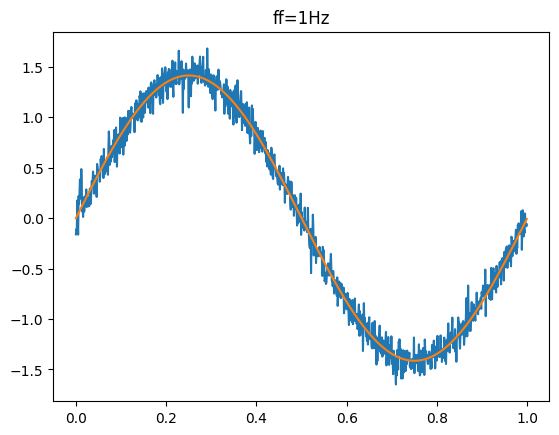

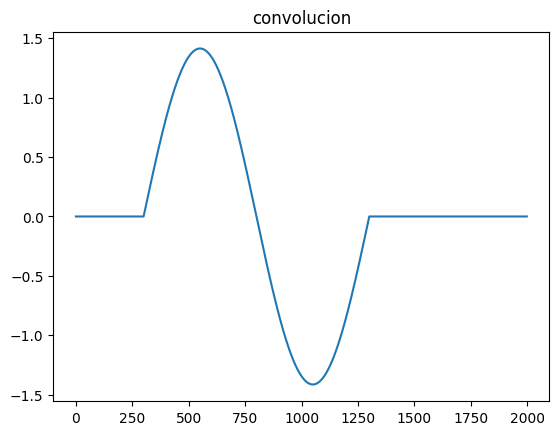

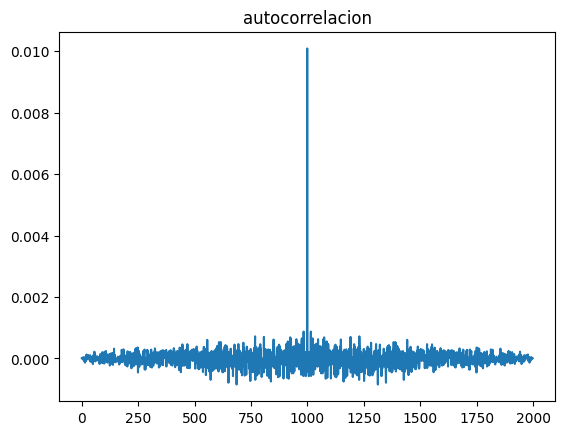

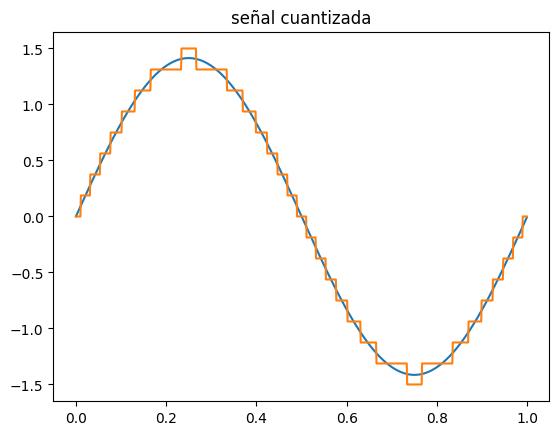

In [6]:
#%% Librerias
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import signal as sig

#%% funcion seno
def mi_funcion_sen (vmax, dc, ff, ph, nn, fs):
        tt= np.arange(nn)/fs
        xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
        return tt, xx

#%% ejecucion
vmax=1
dc=0
ff=1
ph=0
nn=1000
fs=1000

tt,xx=mi_funcion_sen(vmax,dc,ff,ph,nn,fs)
plt.figure(0)
plt.plot(tt, xx)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal Senoidal Generada")
plt.grid(True)
plt.show()

#%% funcion ruido segun dB pedido

vmax=np.sqrt(2)

tt,xx=mi_funcion_sen(vmax,dc,ff,ph,nn,fs)

Px=np.var(xx)
SNR=20
Pr=10**(-SNR/10)
R= np.random.normal(0, np.sqrt(Pr), 1000)

xxn=xx + R

plt.figure(1)
plt.clf()
plt.plot(tt, xxn)
plt.plot(tt,xx)
plt.title(f'ff={ff}Hz')

#%% como usar convolucionar, primero creo una delta

n0= 300 #muestras
dd= np.zeros(nn)
dd[n0]= 1.

yy= sig.convolve(xx,dd)
plt.figure(2)
plt.clf()
plt.plot(yy)
plt.title('convolucion')

#%% autocorrelacion

yyn= (1/nn) * sig.convolve(R, np.flip(R))
plt.figure(3)
plt.clf()
plt.plot(yyn)
plt.title('autocorrelacion')
#%% cuantizacion

B = 4 #bits

Vfs = 3 #Volts

qq= Vfs / (2**B)

xxq= np.round(xx/qq)*qq

exxq= xxq-xx
yyn= (1/nn) * sig.convolve(exxq, np.flip(exxq))
vare=np.var(exxq)
varteoe=qq**2/12

plt.figure(4)
plt.clf()
plt.plot(tt, xx)
plt.plot(tt,xxq)
plt.title('señal cuantizada')

print ("Varianza de error de cuantizacion: ", vare)
print ("varianza teorica de error de cuantizacion: ", varteoe)


Histograma sacado con click derecho histograma sobre la variable exxq (error de cuantizacion)

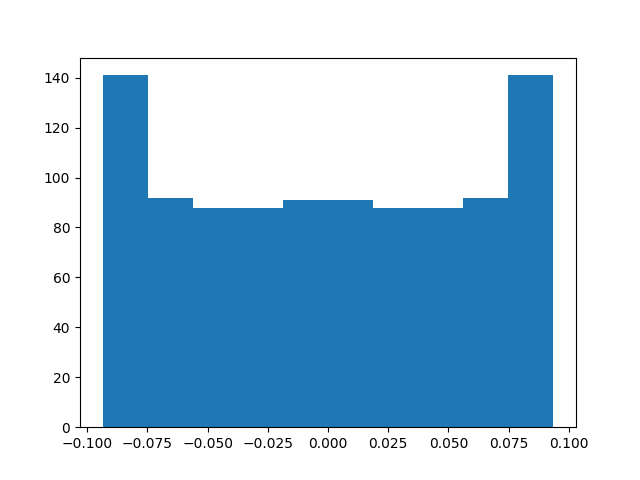